# Milestone 3


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
import plotly.express as px

# Load the dataset


In [14]:
df = pd.read_csv("usnd_cleaned.csv")

In [15]:
print(df.head())
print(df.columns)

  Declaration Number Declaration Type Declaration Date State County  \
0               DR-1         Disaster       1953-05-02    GA    NaN   
1               DR-2         Disaster       1953-05-15    TX    NaN   
2               DR-3         Disaster       1953-05-29    LA    NaN   
3               DR-4         Disaster       1953-06-02    MI    NaN   
4               DR-5         Disaster       1953-06-06    MT    NaN   

  Incident type              Disaster Title  Start Date    End Date  \
0       Tornado                     Tornado  05/02/1953  05/02/1953   
1       Tornado  Tornado and Heavy Rainfall  05/15/1953  05/15/1953   
2         Flood                       Flood  05/29/1953  05/29/1953   
3       Tornado                     Tornado  06/02/1953  06/02/1953   
4         Flood                      Floods  06/06/1953  06/06/1953   

   Close Date Individual Assistance Program Individuals & Households Program  \
0  06/01/1954                           Yes                       

df.head() shows the first 5 rows of the DataFrame and df.columns shows the names of all columns in the dataset.

# Data validation

In [16]:
print(df.isnull().sum())
print(df['State'].unique())
print(len(df))

Declaration Number                      0
Declaration Type                        0
Declaration Date                        0
State                                   0
County                                197
Incident type                           0
Disaster Title                          0
Start Date                              0
End Date                              342
Close Date                          10975
Individual Assistance Program           0
Individuals & Households Program        0
Public Assistance Program               0
Hazard Mitigation Program               0
year                                    0
month                                   0
dtype: int64
['GA' 'TX' 'LA' 'MI' 'MT' 'MA' 'IA' 'NH' 'FL' 'AK' 'MS' 'CA' 'NV' 'SD'
 'WV' 'RI' 'ME' 'CT' 'NY' 'NM' 'NC' 'SC' 'IN' 'HI' 'CO' 'KS' 'OK' 'PA'
 'NJ' 'OR' 'WA' 'ID' 'OH' 'PR' 'KY' 'VA' 'MO' 'AR' 'IL' 'ND' 'MN' 'NE'
 'AL' 'DE' 'MD' 'GU' 'TN' 'FM' 'WY' 'VT' 'VI' 'WI' 'AS' 'AZ' 'PW' 'MP'
 'UT' 'MH' 'DC']
46185


Data validation ensures that the dataset contains consistent state values and no missing records before performing geospatial analysis.


# State-Level Aggregation¶

In [17]:
State_counts = df.groupby('State').size().sort_values(ascending=False)

print(State_counts.head())

State
TX    3842
MO    2263
KY    2026
VA    1982
OK    1882
dtype: int64


Texas has the highest number of disaster declarations (3842), followed by Missouri, Kentucky, Virginia, and Oklahoma. This indicates that southern and central U.S. states experience more natural disasters due to frequent events such as hurricanes, floods, tornadoes, and severe storms. These regions are geographically more vulnerable to extreme weather conditions

# State + Incident Type Aggregation

In [18]:
df.rename(columns={'incidentType': 'Disaster Type'}, inplace=True)

In [19]:
print(df.columns)

Index(['Declaration Number', 'Declaration Type', 'Declaration Date', 'State',
       'County', 'Incident type', 'Disaster Title', 'Start Date', 'End Date',
       'Close Date', 'Individual Assistance Program',
       'Individuals & Households Program', 'Public Assistance Program',
       'Hazard Mitigation Program', 'year', 'month'],
      dtype='object')


In [20]:
State_incident = df.groupby(['State','Incident type']).size().unstack(fill_value=0)

print(State_incident.head())

Incident type  Chemical  Dam/Levee Break  Drought  Earthquake  Fire  Flood  \
State                                                                        
AK                    0                0        0           7    16     46   
AL                    0                0       67           0    11    104   
AR                    0                0       32           0     0    235   
AS                    0                0        5           5     0      5   
AZ                    0                0        8           0    44     77   

Incident type  Human Cause  Hurricane  Ice  Mud/Landslide  Other  Snow  Storm  \
State                                                                           
AK                       0          0    0              0      4     4     64   
AL                       0        368    0              0      0    67    529   
AR                       0         93  207              0      0    17    603   
AS                       0         15    0      

The analysis shows that different states experience different types of disasters. For example, Alabama and Arkansas have a high number of storms, hurricanes, and floods, indicating frequent severe weather events in these regions. Alaska shows more floods, storms, and fires, while Arizona experiences more fires and floods, showing how disaster patterns vary based on geographical and climatic conditions.

# State Comparison Chart (Bar Chart)

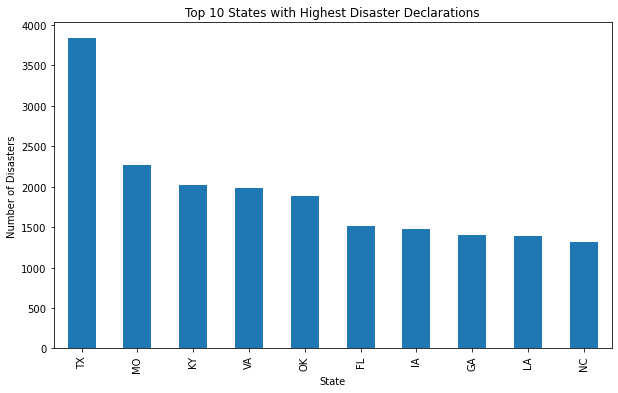

In [21]:
import matplotlib.pyplot as plt

top_states = State_counts.head(10)

plt.figure(figsize=(10,6))
top_states.plot(kind='bar')

plt.title("Top 10 States with Highest Disaster Declarations")
plt.xlabel("State")
plt.ylabel("Number of Disasters")

plt.show()

The bar chart shows the top 10 states with the highest disaster declarations. Texas has the highest number of disasters, followed by Missouri, Kentucky, Virginia, and Oklahoma. This indicates that states in the southern and central regions of the United States are more vulnerable to natural disasters such as storms, floods, hurricanes, and tornadoes.

# Incident Type Distribution by State (Stacked Bar Chart)

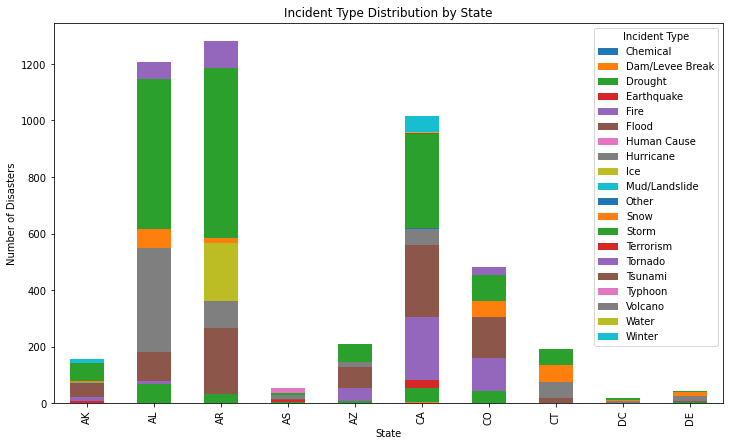

In [22]:
State_incident.head(10).plot(kind='bar', stacked=True, figsize=(12,7))

plt.title("Incident Type Distribution by State")
plt.xlabel("State")
plt.ylabel("Number of Disasters")
plt.legend(title="Incident Type")

plt.show()

The stacked bar chart shows the distribution of different disaster types across the top states. It can be observed that storms, floods, and hurricanes contribute the largest portion of disasters in most states. This indicates that severe weather events are the most common disasters in these regions, while other types such as earthquakes, chemical incidents, and tsunamis occur very rarely.

# Choropleth Map (Geographical Map)

In [24]:
fig = px.choropleth(
    State_counts,
    locations=State_counts.index,
    locationmode="USA-states",
    color=State_counts.values,
    scope="usa",
    title="US Disaster Declarations by State"
)

fig.show()

The choropleth map shows the spatial distribution of disasters across U.S. states. lighter  regions indicate states with higher disaster declarations, highlighting areas that are more vulnerable to natural hazards. This visualization helps identify geographical disaster hotspots.

# Disaster Type Hotspot Map¶

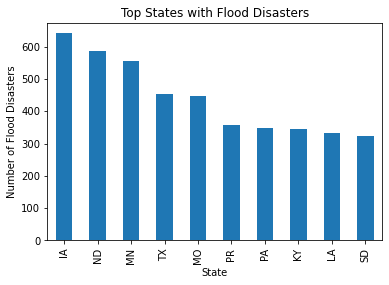

In [23]:
flood_data = df[df['Incident type'] == "Flood"]

flood_counts = flood_data.groupby('State').size().sort_values(ascending=False)

flood_counts.head(10).plot(kind='bar')

plt.title("Top States with Flood Disasters")
plt.xlabel("State")
plt.ylabel("Number of Flood Disasters")

plt.show()

Flood disasters are concentrated in specific states, with some states experiencing significantly higher flood incidents than others. This pattern indicates that certain regions are more vulnerable to flooding due to geographical and climatic conditions.